In [1]:
"""
Plot a grid of Kaplan–Meier survival curves for multiple datasets (Origin + synthetic) 
with domain-specific options for manuscript-quality reproducibility.

Args:
    datasets_dict (Dict[str, pd.DataFrame]): Dictionary mapping dataset names to dataframes.
    dataset_order (List[str], optional): Desired display order of datasets. If None, uses key order.
    phenotype (Dict[str, List[Any]]): {phenotype_col: [GroupA, GroupB]} e.g., {'PBRM1': ['MUT', 'WT']}.
    subset_query (str, optional): Query string to subset data before plotting.
    preprocess_fn (Callable, optional): Function to preprocess each DataFrame before plot. Signature df→df.
    group_labels (Dict[Any, str], optional): Mapping for display names per group/class.
    time_target (str): Survival time column.
    value (str, optional): Label for the time variable axis ("OS", "PFS", etc.).
    event_target (str): Event indicator column.
    ncols (int, optional): Number of columns in grid; ignored for fixed layout (default: 3).
    figsize (Tuple[float, float], optional): Size of matplotlib Figure.
    show_censors (bool): If True, show censoring marks on KM curves.
    ci_show (bool): If True, show confidence intervals.
    title_prefix (str, optional): Prefix for each panel's title.
    title_pad (int, optional): Vertical padding for subplot titles.
    legend_anchor (tuple, optional): Anchor for the legend in axes coordinates.
    show_at_risk (bool): Whether to display at-risk table (not implemented here).

Returns:
    Tuple[matplotlib.figure.Figure, pd.DataFrame]: (Figure object, summary DataFrame for all datasets)
"""

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

# Consistent clinical palette (re-use in all SynOmics survival visuals)
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}
GROUP_COLORS = {
    "GroupA": "#0072B2",  # Okabe-Ito blue
    "GroupB": "#D55E00",  # Okabe-Ito vermillion
}

def plot_survival_grid(
    datasets_dict,
    dataset_order=None,
    phenotype=None,
    subset_query=None,
    preprocess_fn=None,
    group_labels=None,
    time_target="OS",
    value=None,
    event_target="OS_CNSR",
    ncols=3,
    figsize=(18, 7),
    show_censors=True,
    ci_show=False,
    title_prefix="",
    title_pad=10,
    legend_anchor=(0, 0.00),
    show_at_risk=False,
):
    """
    Plot a grid of Kaplan–Meier survival curves for multiple datasets.

    Args:
        datasets_dict (Dict[str, pd.DataFrame]): Source data for each panel.
        ...
        # (Arguments as above in module docstring)

    Returns:
        Tuple[matplotlib.figure.Figure, pd.DataFrame]: (Figure, summary dataframe)
    """
    # ------------------- Validation and Ordering -------------------
    if phenotype is None or len(phenotype) != 1:
        raise ValueError("phenotype must be provided as {col: [GroupA, GroupB]} for color coding.")
    ph_col, ph_vals = next(iter(phenotype.items()))
    if not isinstance(ph_vals, (list, tuple)) or len(ph_vals) != 2:
        raise ValueError("phenotype must be {col: [A, B]}")

    groupA, groupB = ph_vals
    group_labels = group_labels or {groupA: str(groupA), groupB: str(groupB)}

    if dataset_order is None:
        dataset_order = list(datasets_dict.keys())
    if "Origin" in dataset_order:
        dataset_order = ["Origin"] + [d for d in dataset_order if d != "Origin"]
    else:
        dataset_order = list(datasets_dict.keys())

    datasets_list = [datasets_dict[k].copy() for k in dataset_order]

    # ------------ Figure & Grid Layout: 2 rows x 4 cols -------------
    plt.style.use(["science", "nature", "notebook"])
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "text.usetex": False,
        "axes.edgecolor": "#222",
        "xtick.top": False,
        "ytick.right": False,
    })

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.11, hspace=0.27,
                           width_ratios=[2, 1.3, 1.3, 1.3], height_ratios=[1, 1])

    # ----------- Panel allocation ---------------
    ax_origin = fig.add_subplot(gs[:, 0])
    ax_origin.set_box_aspect(1)
    small_axes = []
    for r in range(2):
        for c in range(1, 4):
            small_axes.append(fig.add_subplot(gs[r, c]))
    max_small = len(small_axes)
    panel2name = ["Origin"] + [d for d in dataset_order if d != "Origin"]

    # ----------- Plot logic per panel -----------
    summary_rows = []
    for i, name in enumerate(panel2name):
        df = datasets_dict[name].copy()
        # Subset and preprocess
        if subset_query is not None:
            df = df.query(subset_query)
        if preprocess_fn is not None:
            df = preprocess_fn(df)
        # Group assignment
        dfA = df[df[ph_col] == groupA]
        dfB = df[df[ph_col] == groupB]

        nA, nB = len(dfA), len(dfB)
        ax = ax_origin if i == 0 else small_axes[i-1]
        ds_color = DATASET_COLORS.get(name, "#cccccc")

        # Strip color for dataset annotation
        ax.add_patch(
            plt.Rectangle(
                (0, 1.01), 1, 0.02, transform=ax.transAxes, facecolor=ds_color,
                edgecolor="none", clip_on=False, zorder=11,
            )
        )

        # --- KM plot ---
        color_A = GROUP_COLORS["GroupA"]
        color_B = GROUP_COLORS["GroupB"]
        kmf = KaplanMeierFitter()
        plotted = False

        def _plot_group(group_df, label, color):
            nonlocal plotted
            if group_df[time_target].dropna().empty:
                return
            g = group_df.dropna(subset=[time_target, event_target])
            if len(g) == 0:
                return
            kmf.fit(g[time_target], event_observed=g[event_target], label=label)
            kmf.plot_survival_function(
                ax=ax, ci_show=ci_show, show_censors=show_censors,
                color=color, linewidth=2.0 if i == 0 else 1.7,
                censor_styles={"ms": 4, "marker": "|", "mew": 1.3} if show_censors else None,
            )
            plotted = True

        _plot_group(dfB, f"{group_labels[groupB]} (n={nB})", color_B)
        _plot_group(dfA, f"{group_labels[groupA]} (n={nA})", color_A)

        # --- Statistics ---
        pvalue = np.nan
        try:
            if nA > 0 and nB > 0:
                res = logrank_test(
                    dfA[time_target], dfB[time_target],
                    event_observed_A=dfA[event_target], event_observed_B=dfB[event_target]
                )
                pvalue = float(res.p_value)
        except Exception:
            pvalue = np.nan

        cindex_text = "NA"
        try:
            df_cox = df[[time_target, event_target]].copy()
            df_cox["binary"] = pd.NA
            df_cox.loc[df[ph_col] == groupA, "binary"] = 1
            df_cox.loc[df[ph_col] == groupB, "binary"] = 0
            df_cox_fit = df_cox.dropna(subset=[time_target, "binary"])
            df_cox_fit[time_target] = pd.to_numeric(df_cox_fit[time_target], errors="coerce")
            df_cox_fit = df_cox_fit.dropna(subset=[time_target])
            df_cox_fit["binary"] = df_cox_fit["binary"].astype(int)
            if (len(df_cox_fit) > 0
                and df_cox_fit["binary"].nunique() > 1
                and df_cox_fit[event_target].sum() > 0):
                cph = CoxPHFitter()
                cph.fit(df_cox_fit, duration_col=time_target, event_col=event_target, show_progress=False)
                partial_h = cph.predict_partial_hazard(df_cox_fit)
                cindex = concordance_index(df_cox_fit[time_target], -partial_h, df_cox_fit[event_target])
                cindex_text = f"{cindex:.3f}"
            else:
                cindex_text = "insufficient events"
        except Exception:
            cindex_text = "fit error"

        # --- Axes, titles, legend ---
        ptxt = "p = NA" if np.isnan(pvalue) else f"p = {pvalue:.4g}"
        ax.text(0.98, 0.96, ptxt, transform=ax.transAxes, fontsize=12,
                horizontalalignment="right", verticalalignment="top", zorder=12)
        ax.text(0.98, 0.88, f"C-index: {cindex_text}", transform=ax.transAxes, fontsize=12,
                horizontalalignment="right", verticalalignment="top", zorder=12)

        raw_short_title = name.replace("_", " ")
        panel_title = (f"{title_prefix} — {raw_short_title}" if title_prefix else raw_short_title)
        ax.set_title(panel_title, fontweight="bold", pad=title_pad)
        ax.set_xlabel(f"Time ({value or time_target})")
        ax.set_ylabel("Survival probability" if i == 0 else "")
        ax.set_ylim(0, 1.02)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

        if plotted:
            ax.legend(frameon=True, framealpha=1.0, loc="lower left", bbox_to_anchor=legend_anchor, borderaxespad=0.2)
        else:
            ax.text(0.5, 0.5, "No valid survival data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            if ax.get_legend(): ax.get_legend().remove()

        summary_rows.append({
            "Dataset": name,
            "pvalue": None if np.isnan(pvalue) else float(pvalue),
            "C-index": cindex_text,
            "n_A": int(nA),
            "n_B": int(nB),
        })

    # Hide unused axes (if any)
    for j in range(1 + len(datasets_list), 1 + max_small):
        if j-1 < len(small_axes):
            small_axes[j-1].axis("off")

    plt.tight_layout()
    summary_df = pd.DataFrame(summary_rows, columns=["Dataset", "pvalue", "C-index", "n_A", "n_B"])
    summary_df["Dataset"] = pd.Categorical(summary_df["Dataset"], categories=panel2name, ordered=True)
    summary_df = summary_df.sort_values("Dataset").reset_index(drop=True)
    return fig, summary_df

In [3]:
import pandas as pd
import numpy as np
import sys
from SynOmics.processing.postprocessing import post_masking
import scipy.stats as scp
# from visulize_grid import plot_survival_grid

corr_res = {}

def create_merged_clinical(dataset):
    if dataset == 'Origin':
        data = 'original_data'
    else:
        data = dataset
    raw_clinical = pd.read_csv(f'../NSCLC/Data/{data}.csv')
    un_mask_su2c_clinical = raw_clinical.iloc[:,0:29]
    su2c_clinical = post_masking(un_mask_su2c_clinical)
    su2c_clinical = su2c_clinical.rename(columns= {
        'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
    })
    su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
        'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
        'SD': 0, 'PD': 0
    })

    su2c_is_sf_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/SF_{dataset}.csv')
    su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_zi_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/ZI_{dataset}.csv')
    su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_hm_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/Other_{dataset}.csv')
    su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

    su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

    expression_data = raw_clinical.set_index('Patient_ID', drop=True).iloc[:, 28:]
    expression_data = expression_data.T
    expression_matrix = (expression_data
                     .replace([np.inf, -np.inf], 0)
                     .fillna(0)
                     .clip(lower=0))
    expression_data_log = expression_matrix.apply(lambda x: np.log(x+1))
    expression_data_log_norm = expression_data_log.T.apply(scp.zscore).T
    interested_genes = ['NHSL2', 'SLC27A3', 'SIPA1L2','AUTS2','TCF7L1','PRPF40A',
             'PSMB9','PSME1','PSME2']
    expression_data_log_norm_selected = expression_data_log_norm.loc[interested_genes]

    su2c_rna_harm_log_merge_mine = expression_data_log_norm_selected.T.merge(su2c_merge_master,left_index=True,
                                                                             right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')
    su2c_rna_harm_log_merge_mine.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',inplace=True)
    return su2c_rna_harm_log_merge_mine

/tmp/ipykernel_887544/3772957222.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cox_fit[time_target] = pd.to_numeric(df_cox_fit[time_target], errors="coerce")
/tmp/ipykernel_887544/3772957222.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cox_fit[time_target] = pd.to_numeric(df_cox_fit[time_target], errors="coerce")
/tmp/ipykernel_887544/3772957222.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

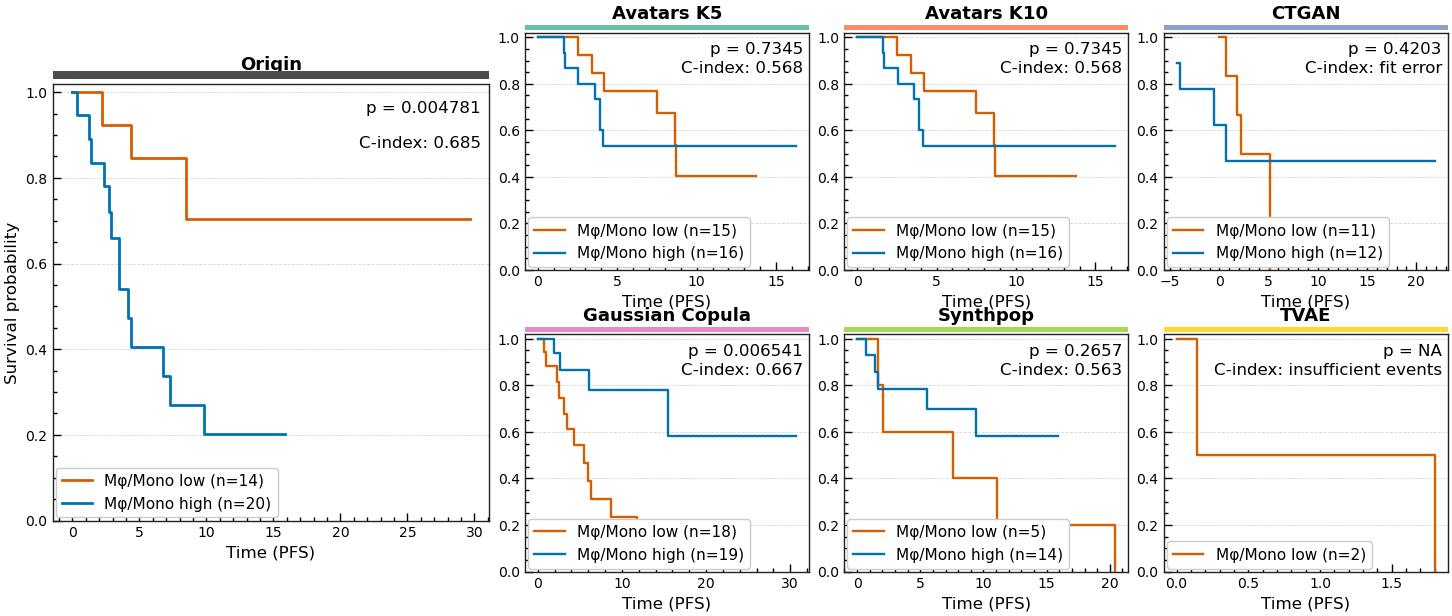

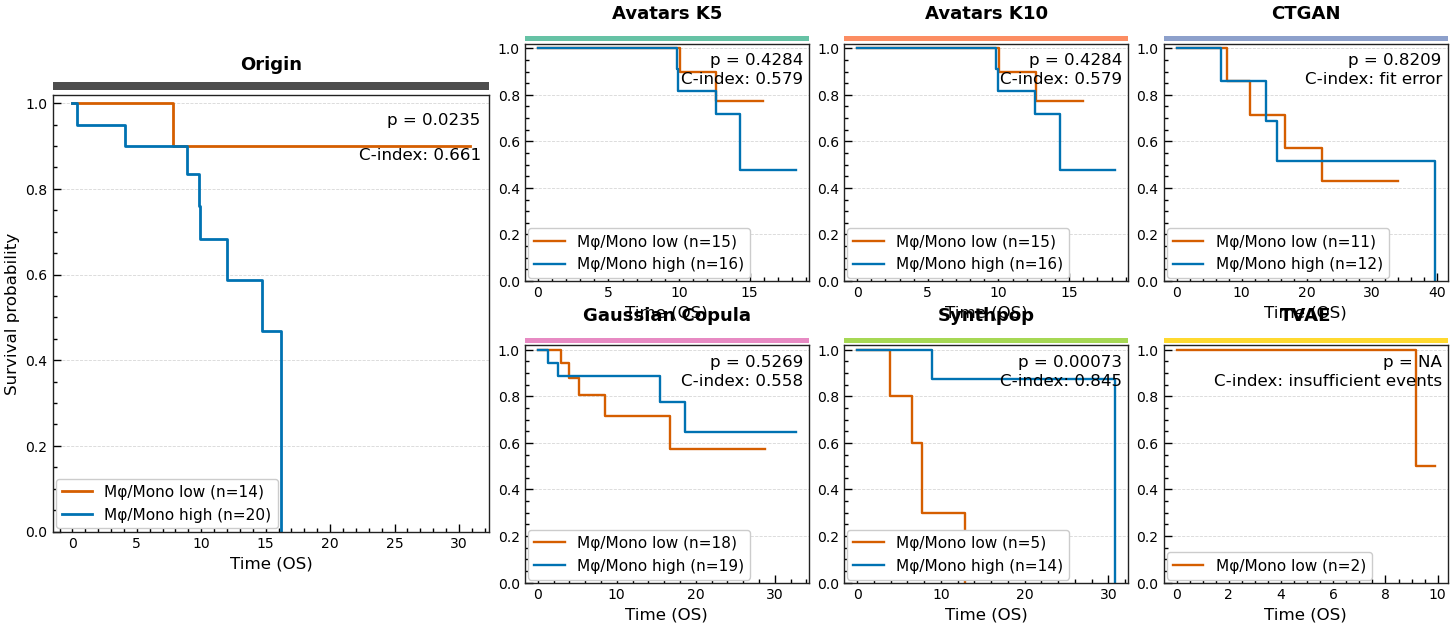

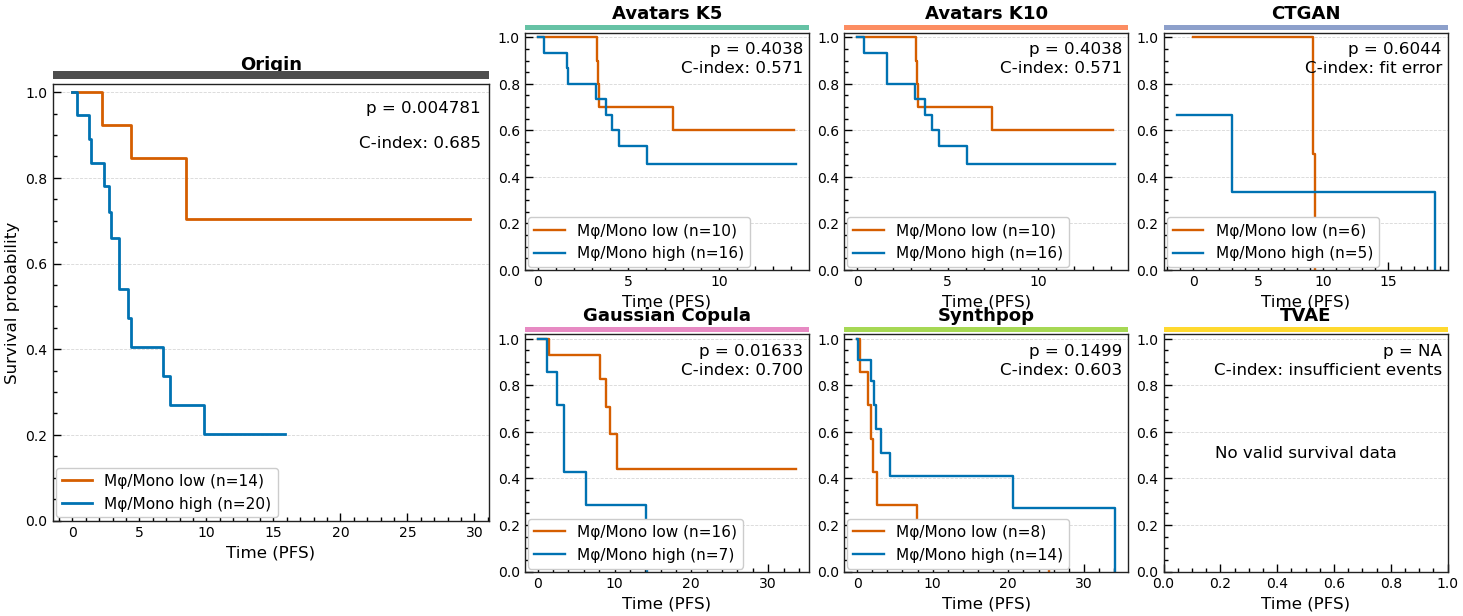

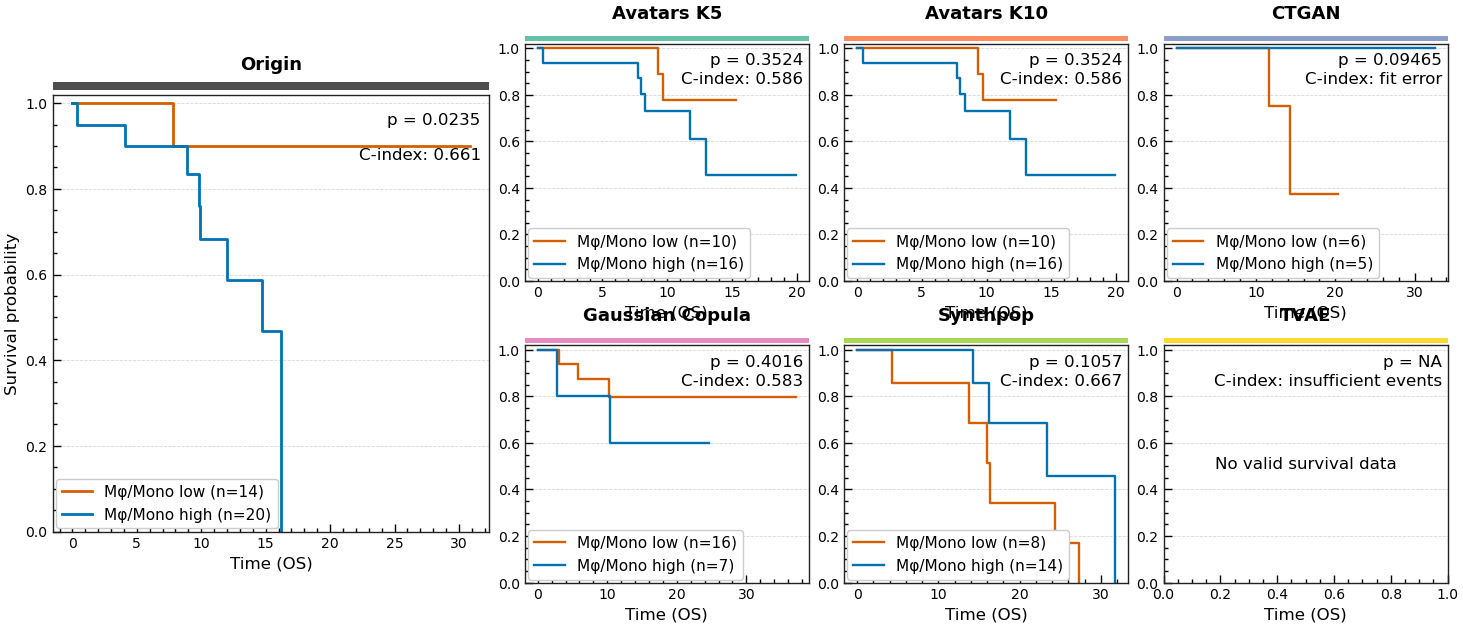

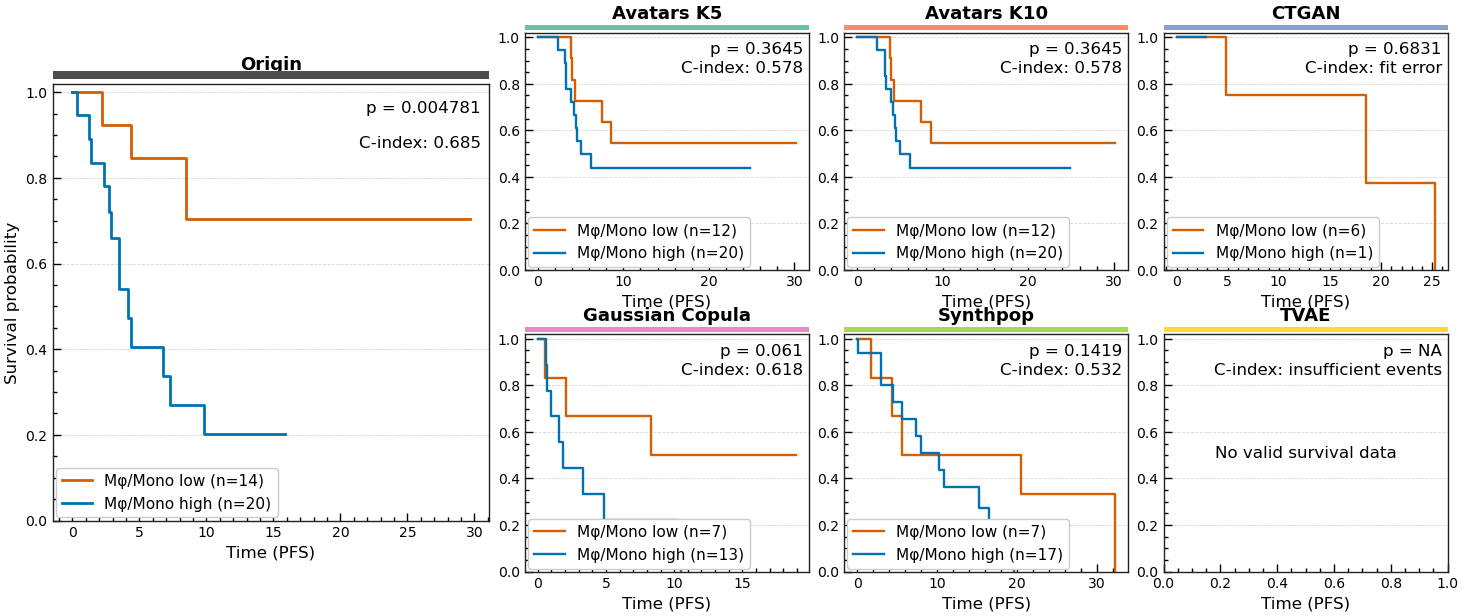

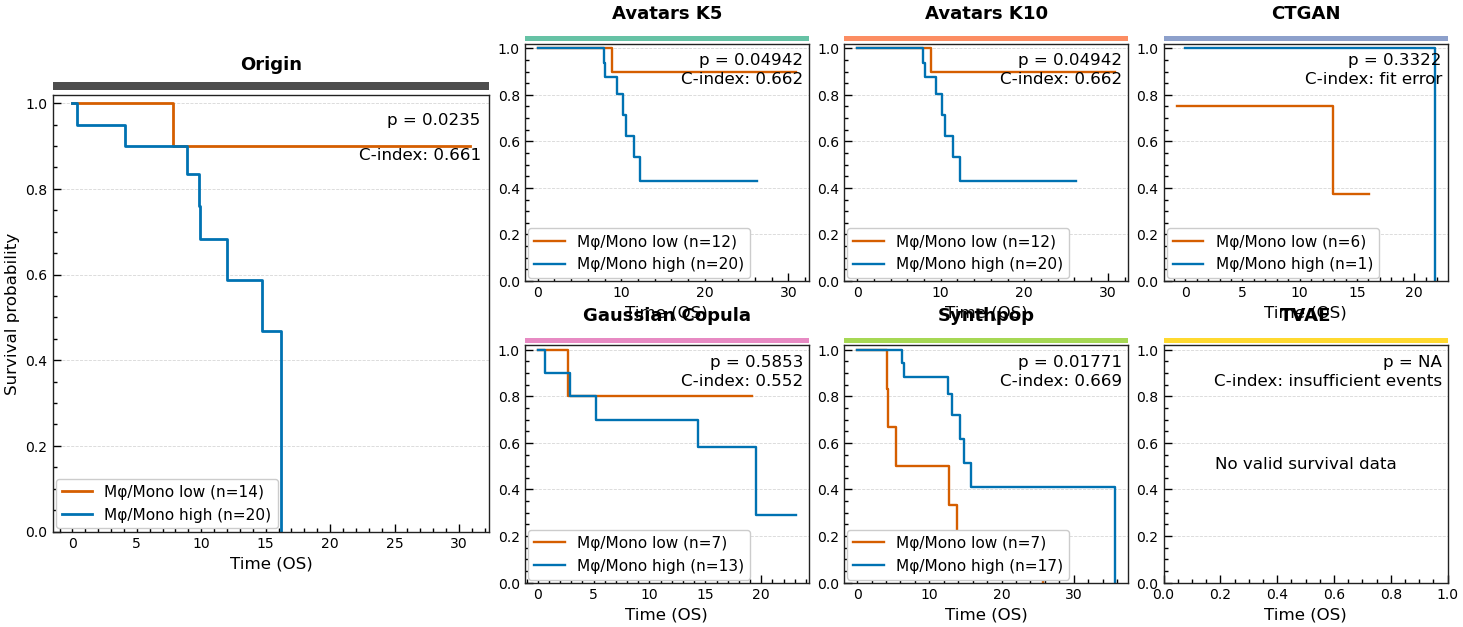

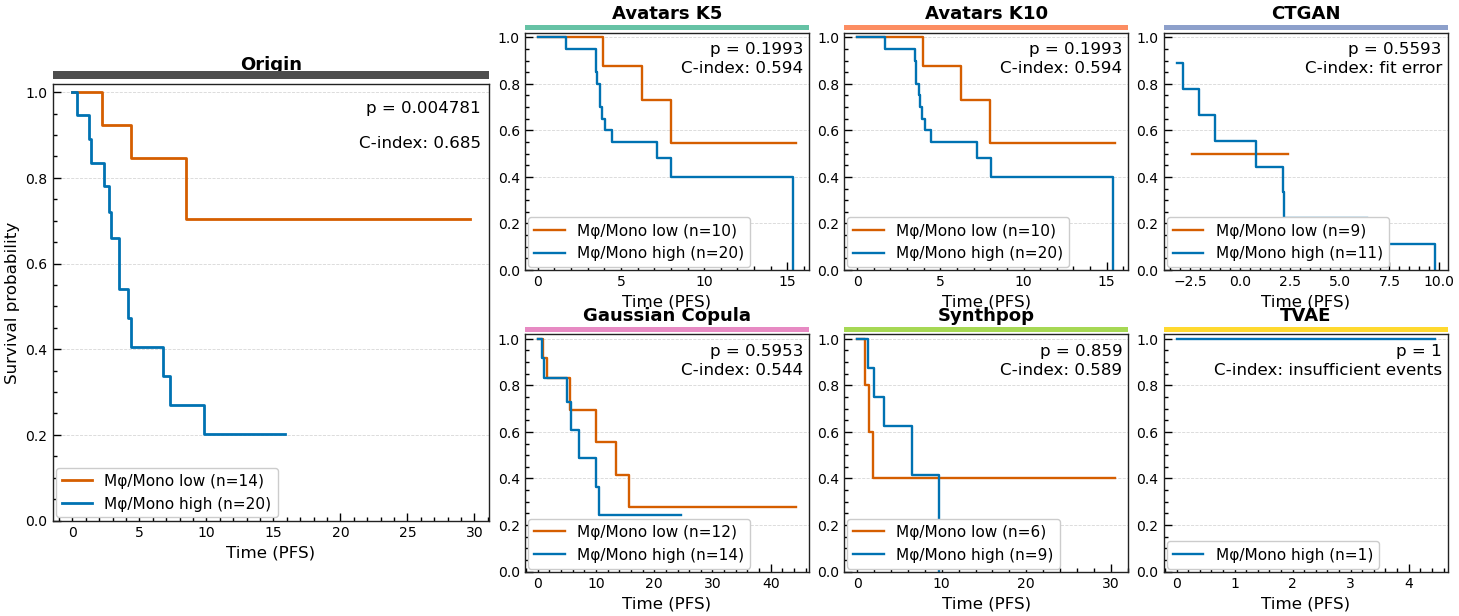

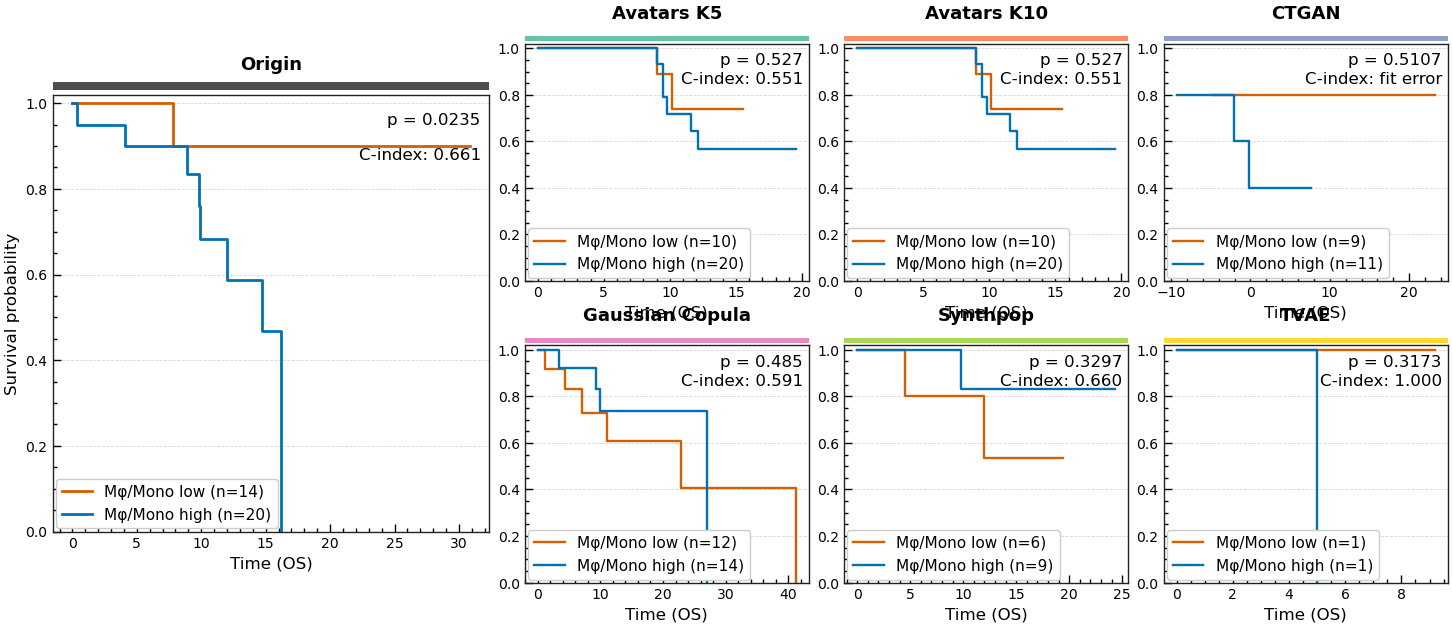

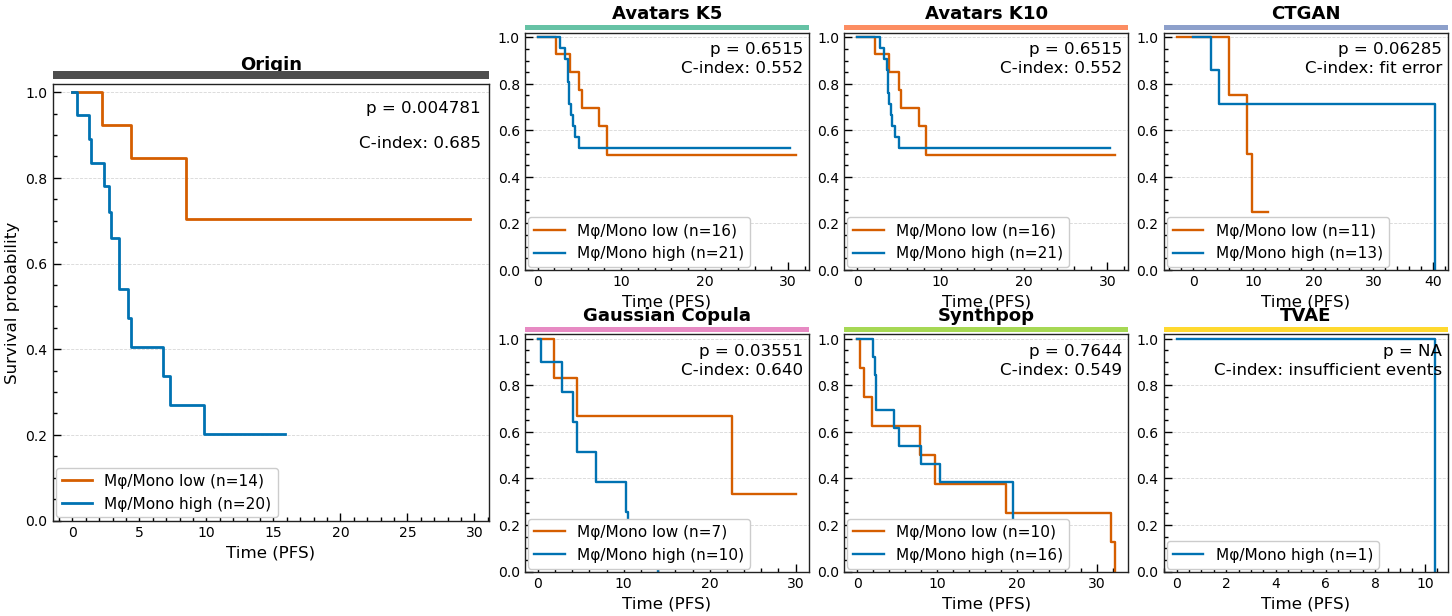

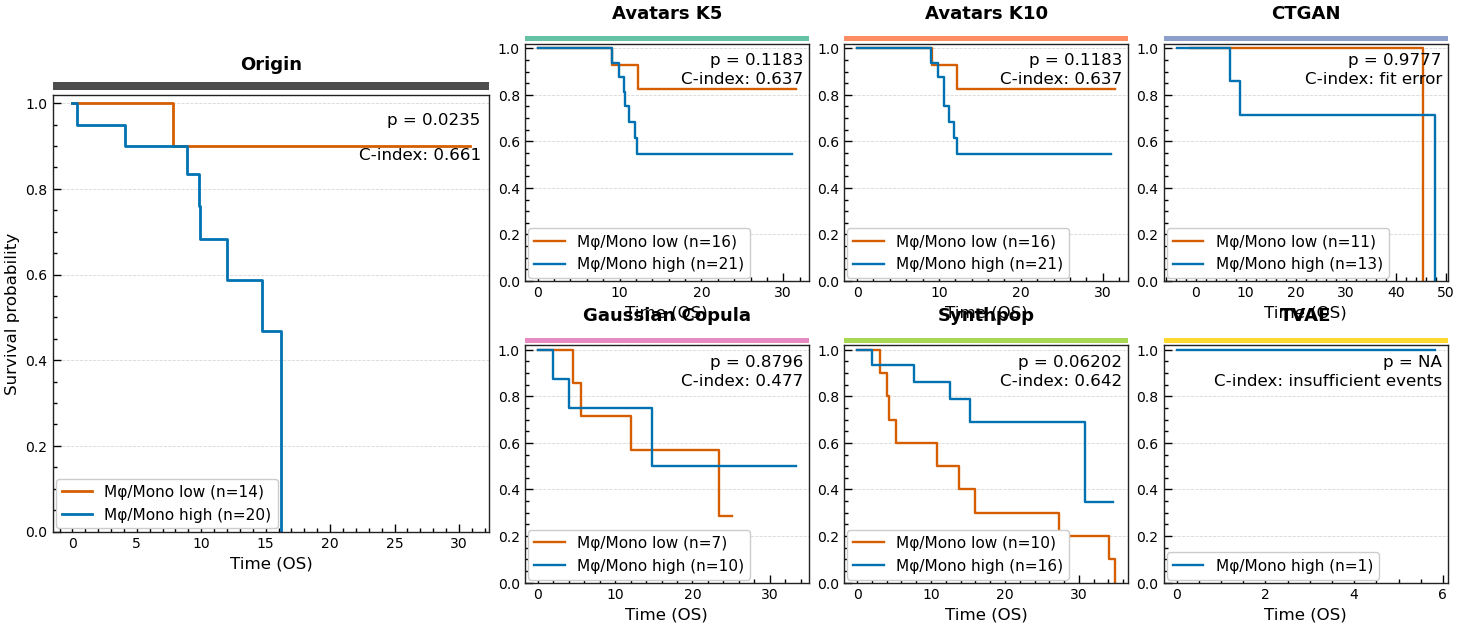

In [5]:
import scienceplots
# seeds = [0]
seeds = [0,1,2,3,42]
for seed in seeds:
    metadata_dict = {}
    datasets = ['Origin', f'avatarsk5_{seed}', f'avatarsk5_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', 
                f'synthpop_{seed}', f'tvae_{seed}']
    names = ["Origin", "Avatars K5", 'Avatars K10','CTGAN',"Gaussian Copula", "Synthpop", "TVAE"]
    
    for i, dataset in enumerate(datasets):
    
        metadata = create_merged_clinical(dataset)
        metadata_dict[names[i]]=metadata
    
    
    feature_col = "Macrophages/Monocytes_SF"
    duration_col = "Harmonized_PFS_Months"
    event_col = "Harmonized_PFS_Event"
    
    def preprocess_macrophage_high_low(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df[feature_col] = pd.to_numeric(df[feature_col], errors="coerce").fillna(0)
        df[feature_col] = df[feature_col] > 0
        return df
    
    fig, summary = plot_survival_grid(
        datasets_dict=metadata_dict,  # {"Origin": df, "Avatars K5": df, ...}
        dataset_order=[
            "Origin",
            "Avatars K5",
            "Avatars K10",
            "CTGAN",
            "Gaussian Copula",
            "Synthpop",
            "TVAE",
        ],
        phenotype={feature_col: [True, False]},
        subset_query="PDL1_TPS >= 0.5",
        preprocess_fn=preprocess_macrophage_high_low,
        group_labels={True: "Mφ/Mono high", False: "Mφ/Mono low"},
        time_target=duration_col,
        value="PFS",
        event_target=event_col,
        # ncols bị bỏ qua trong layout mới, nên không cần truyền hoặc để mặc định
        figsize=(18, 7),          # hoặc None để dùng default trong hàm
        show_censors=False,
        ci_show=False,
        title_prefix="",
        title_pad=10,
        legend_anchor=(0, 0.00),
        show_at_risk=False,       # hàm hiện không vẽ at-risk table, nên để False
    )

    
    feature_col = "Macrophages/Monocytes_SF"
    duration_col = "Harmonized_OS_Months"
    event_col = "Harmonized_OS_Event"
    
    
    fig_os, summary = plot_survival_grid(
        datasets_dict=metadata_dict,  # {"Origin": df, "Avatars K5": df, ...}
        dataset_order=["Origin", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"],
        phenotype={feature_col: [True, False]},             # True vs False
        subset_query="PDL1_TPS >= 0.5",                     # giống code của bạn
        preprocess_fn=preprocess_macrophage_high_low,
        group_labels={True: "Mφ/Mono high", False: "Mφ/Mono low"},
        time_target=duration_col,
        value = 'OS',
        event_target=event_col,
        ncols=3,                                            # grid 7 panels
        figsize=(18,7),
        show_censors=False,
        ci_show=False,
        title_prefix="",
        title_pad=18,
        legend_anchor=(0, 0.00),                            # nâng legend lên chút
        show_at_risk=True,                                  # giống add_at_risk_counts
    )
    
    # fig.savefig("NSCLC_ZI_KMCurve.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"SA_ZI/PFS_ZI_KMCurve_{seed}.pdf", dpi=300, bbox_inches="tight")
    fig_os.savefig(f"SA_ZI/OS_ZI_KMCurve_{seed}.pdf", dpi=300, bbox_inches="tight")